In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from colliderml_electron import io, plots

REPO_ROOT = Path.cwd()

while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

print("Repo root:", REPO_ROOT)

Repo root: /Users/loiclambert/code/colliderml-electron-calo


/Users/loiclambert/code/colliderml-electron-calo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# load data
io.load_frames(channel="zee", pileup="pu200", max_events=50)

frames = io.load_frames(
    channel="zee",
    pileup="pu200",
    max_events=2,
)

frames.keys()

# inspect variables
print("particles:", frames["particles"].shape)
print("calo_hits:", frames["calo_hits"].shape)

frames["particles"].head()

particles: (2, 18)
calo_hits: (2, 9)


event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary
u32,list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool]
0,"[87, 88, … 189276]","[211, 2112, … -11]","[0.13957, 0.93957, … 0.000511]","[18.075972, 33.929401, … 0.174953]","[1.0, 0.0, … 1.0]","[-0.005843, -0.005843, … -90.340004]","[-0.008313, -0.008313, … -1327.538818]","[4.793712, 4.793712, … 2497.082275]","[-0.130097, -0.130097, … 9.296101]","[0.011057, 0.064316, … -0.003404]","[-8.521785, -15.48398, … -0.047415]","[15.940525, 30.175547, … 0.16837]","[-0.005853, -0.005877, … NaN]","[4.778176, 4.777559, … NaN]","[1, 1, … 1]","[7, 7, … 189267]","[true, true, … false]"
1,"[17, 18, … 191777]","[-211, 2224, … 22]","[0.13957, 1.216394, … 0.0]","[629.288269, 5786.586914, … 0.134977]","[-1.0, 2.0, … 0.0]","[-0.000053, -0.000053, … 8.599925]","[-0.006959, -0.006959, … -22.527786]","[-57.350899, -57.350899, … 1118.791382]","[-0.06167, -0.06167, … 3.862343]","[0.02498, -0.02498, … 0.001078]","[-0.047174, 0.047174, … -0.002464]","[629.288208, 5786.586914, … 0.13495]","[NaN, NaN, … -1.152959]","[NaN, NaN, … -89.642792]","[1, 1, … 1]","[10, 10, … 191774]","[true, true, … false]"


In [12]:
p_row, c_row = io.get_event(frames, 0)
electrons = io.prompt_electrons(p_row)

print(f"Number of prompt electrons in event 0: {len(electrons)}")
electrons

Number of prompt electrons in event 0: 2


[{'particle_id': 233,
  'pdg_id': 11,
  'px': 12.084962844848633,
  'py': -28.288488388061523,
  'pz': 9.763503074645996,
  'energy': 32.27399826049805},
 {'particle_id': 234,
  'pdg_id': -11,
  'px': 4.62752628326416,
  'py': 64.30288696289062,
  'pz': 66.0659408569336,
  'energy': 92.30917358398438}]

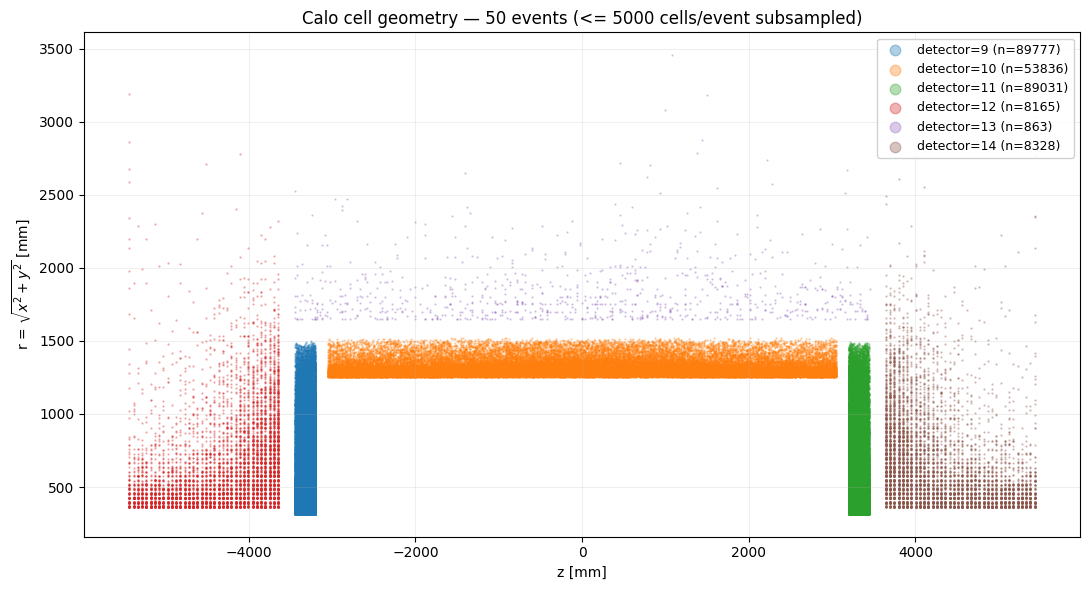

In [14]:
# show calorimeter cell geometry in the rz plane
fig = plots.detector_geometry(
    frames,
    n_events=50,
    max_cells_per_event=5000,
)
plt.show()

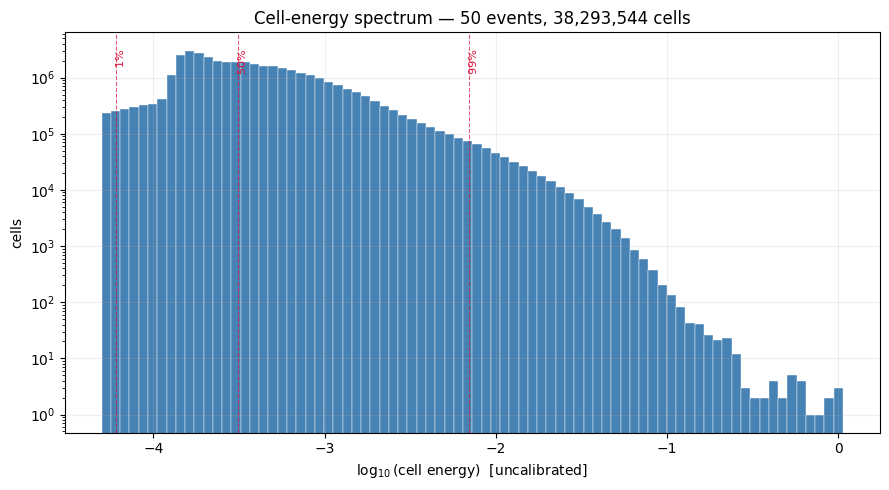

In [13]:
# show cell energy spectrum
# distribution of calorimeter cell energies on a log scale
fig = plots.cell_energy_spectrum(
    frames,
    n_events=50,
    bins=80,
)
plt.show()

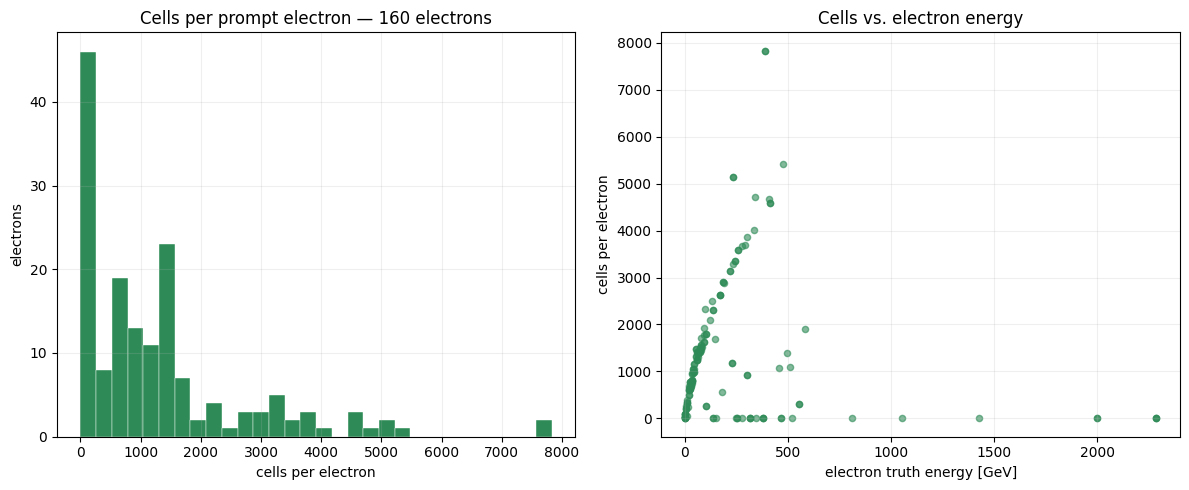

In [15]:
# show how many calorimeter cells are associated with each prompt electron
# show how calorimeter cell number changes with the electron truth energy
fig = plots.cells_per_electron(
    frames,
    n_events=50,
)
plt.show()

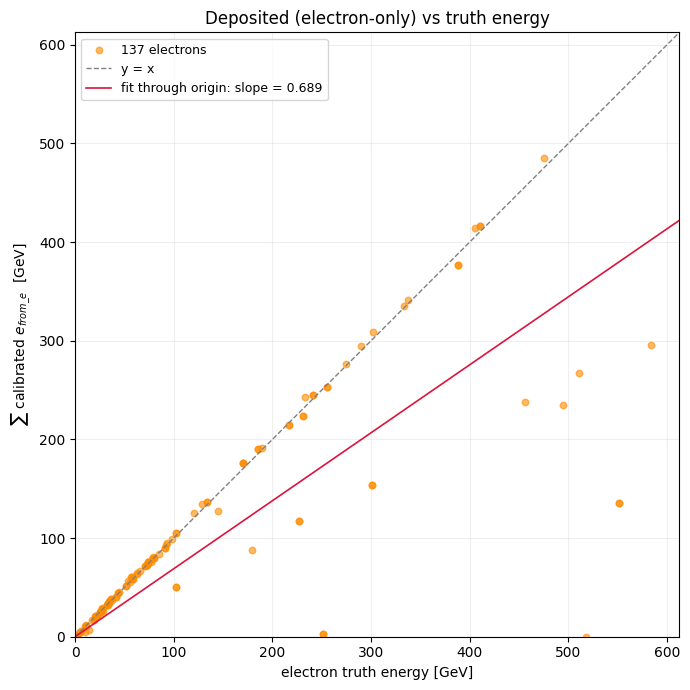

In [16]:
# show energy deposited into the calorimeter compared to the energy of the electron
fig = plots.deposited_vs_truth(
    frames,
    n_events=50,
)
plt.show()

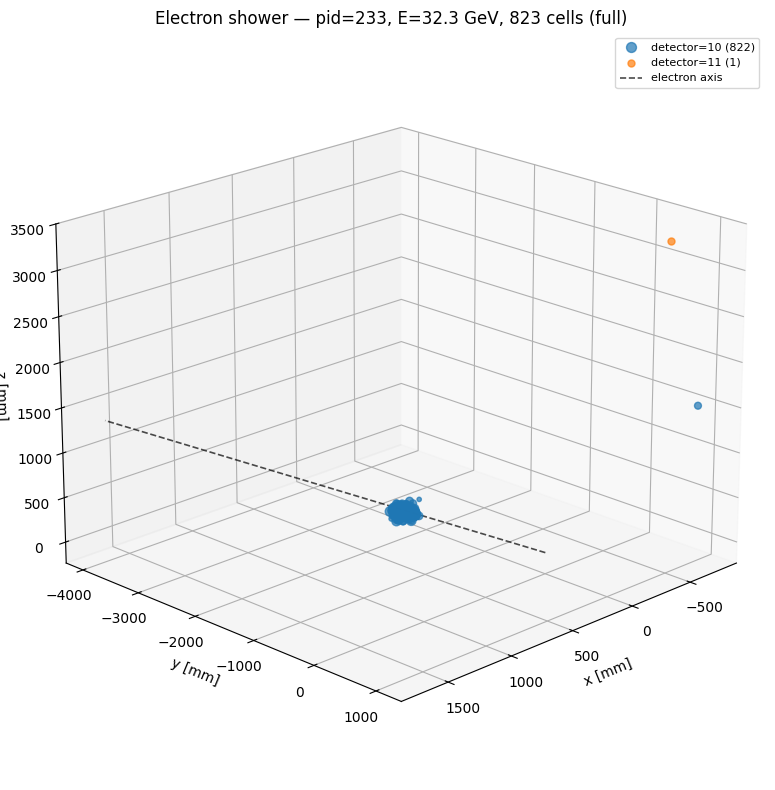

In [6]:
# show one 3d shower
p_row, c_row = io.get_event(frames, 0)
electrons = io.prompt_electrons(p_row)

electron_pid = electrons[0]["particle_id"]

fig = plots.shower_3d(
    p_row,
    c_row,
    electron_pid=electron_pid,
    full_shower=True,
)
plt.show()

In [ ]:
fig = plots.shower_3d(
    p_row,
    c_row,
    electron_pid=electron_pid,
    full_shower=True,
    clean_outliers=True,
    containment=0.98,
)
plt.show()


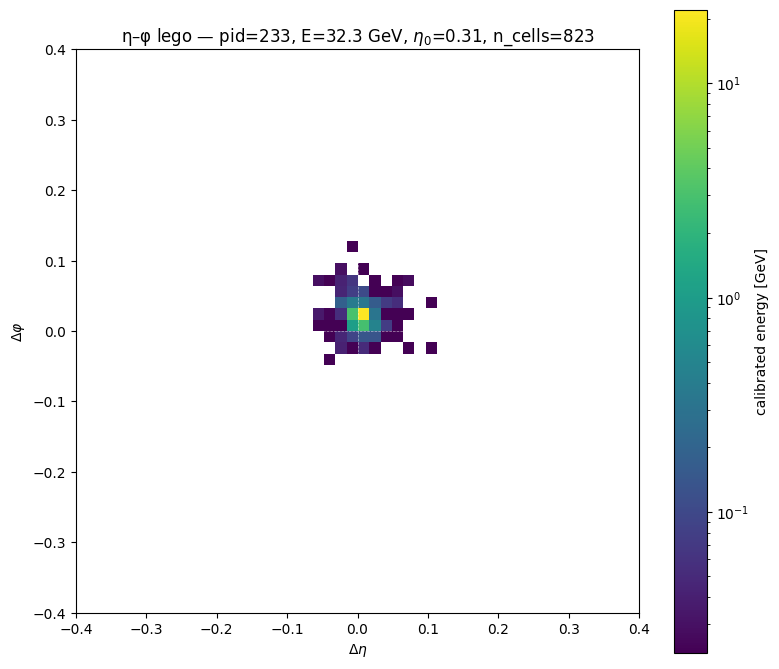

In [7]:
fig = plots.shower_eta_phi_lego(
    p_row, 
    c_row, 
    electron_pid=electron_pid,
    full_shower=True,
)

plt.show()

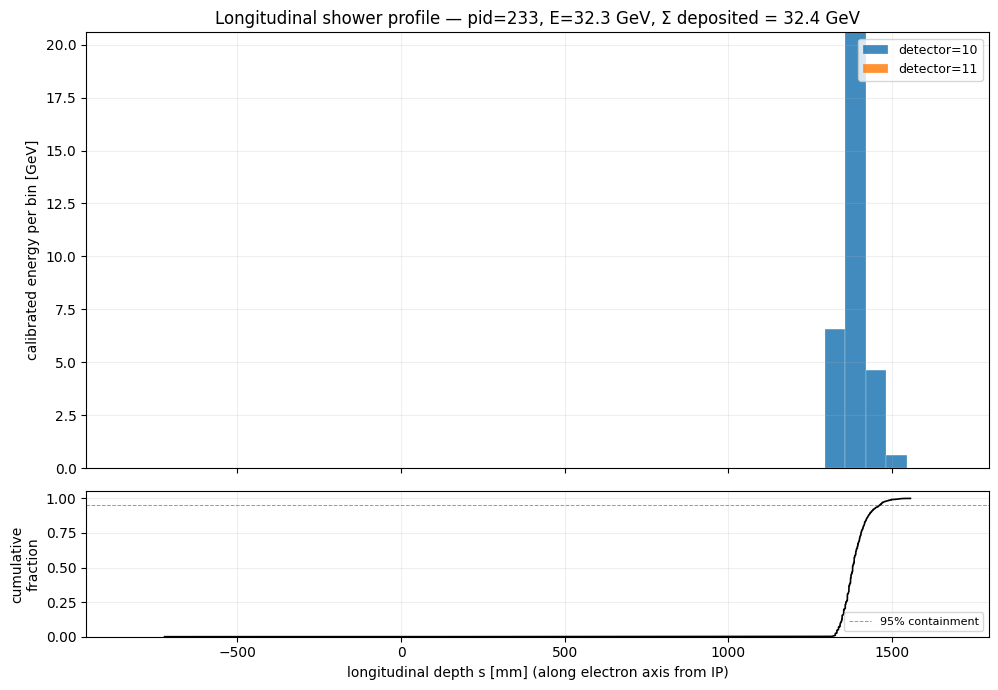

In [8]:
fig = plots.shower_longitudinal_profile(
    p_row, 
    c_row, 
    electron_pid=electron_pid,
    full_shower=True,
)

plt.show()